In [1]:
import pandas as pd
import pickle
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from scipy.stats import chi2
import textwrap

# Dependency
* DGIDB_hypergraph
* Clustering_Result_Analysis

# Loading Variables

In [2]:
DISEASE = input("Disease: ")
DISEASE_FOLDER = f"../output/{DISEASE}/"
DGIDB_DIRECTORY = f"../../Gen_Hypergraph/output/DGIDB_{DISEASE}/"

# Comm DGIDB genes count

In [3]:
def DGIDB_count(c,DGIDB_genes_ncbi):
    return set(c) & set(DGIDB_genes_ncbi)

In [4]:
with open(f"{DISEASE_FOLDER}/result_communities_ncbi_selected.pkl", "rb") as f:
    communities_ncbi_selected = pickle.load(f)
with open(f"{DISEASE_FOLDER}/result_communities_ncbi.pkl", "rb") as f:
    communities_ncbi = pickle.load(f)
with open(DGIDB_DIRECTORY + f"gene_to_index.json", "r") as file:
    DGIDB_gene_to_index = json.load(file)
DGIDB_genes = set(DGIDB_gene_to_index.keys())

In [5]:
comm_dgidb_gene_count = {}
for i in range(len(communities_ncbi_selected)):
    dgidb_genes_set = DGIDB_count(communities_ncbi[i],DGIDB_genes)
    print(i,len(dgidb_genes_set), dgidb_genes_set)
    print(len(communities_ncbi[i]))
    comm_dgidb_gene_count[i] = len(dgidb_genes_set)
    
with open(f"../output/{DISEASE}/comm_dgidb_gene_count.json","w") as f:
    json.dump(comm_dgidb_gene_count,f)    

0 8 {'4922', '7133', '6750', '3107', '6331', '4915', '355', '5617'}
3841
1 0 set()
3652
2 0 set()
3576
3 0 set()
3097
4 0 set()
2352
5 133 {'1543', '2696', '1815', '3350', '477', '3127', '2944', '25', '1562', '1814', '24', '152', '84062', '4160', '255239', '4781', '3359', '218', '1571', '4835', '3952', '3363', '718', '28755', '2641', '10919', '217', '59340', '50852', '259232', '319100', '3351', '2740', '2675', '196', '148', '367', '3354', '1131', '3778', '3269', '693167', '3699', '5565', '1', '1103', '5144', '26', '4363', '155', '5325', '3558', '26298', '9429', '5468', '3552', '23216', '2194', '153', '7957', '64478', '6714', '147', '7172', '3358', '152330', '887', '5999', '2904', '2548', '5294', '3362', '2668', '3760', '2166', '1813', '2784', '3727', '1129', '23', '2328', '11201', '3115', '2', '262', '2671', '6505', '1544', '3357', '1816', '22', '64816', '1576', '12', '339745', '3176', '1002', '1559', '9135', '5563', '25970', '150', '440275', '1128', '6580', '115019', '216', '3', '3352

# important terms processing

In [6]:
with open(f"{DISEASE_FOLDER}/result_communities_selected.pkl", "rb") as f:
    communities_selected = pickle.load(f)

In [7]:
important_terms = pd.read_csv(DISEASE_FOLDER + "important_terms.csv")

In [8]:
important_terms = important_terms.sort_values(
    by=["Community Index", "Adjusted P-value"],
    ascending=[True, True]
).reset_index(drop=True)

In [9]:
important_terms

,Community Index,Community Size,Term,Overlap,Adjusted P-value,Category,Gene_set,P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Overlap (value)
0,0,1520,Cytokine-cytokine receptor interaction,135/295,6.142958e-70,['Signaling molecules and interaction'],KEGG_2021_Human,2.792254e-72,0.0,0.0,11.160650,1838.820602,IL1RN;TNFRSF6B;CSF3R;CSF1;CXCL17;IL1RAP;CXCL13...,0.457627
1,0,1520,Immune System R-HSA-168256,355/1943,1.228460e-57,['Immune System'],Reactome_2022,1.765029e-60,0.0,0.0,3.241403,445.974687,IFITM3;IFITM1;IL1RN;TNFRSF6B;IFITM2;GMFG;CLEC1...,0.182707
2,0,1520,Collagen-Containing Extracellular Matrix (GO:0...,133/373,5.099171e-53,[],GO_Cellular_Component_2023,2.416669e-55,0.0,0.0,7.287671,916.496004,ADAMDEC1;SPARC;COL16A1;SERPINE2;SERPINE1;LOXL3...,0.356568
3,0,1520,Cytokine Signaling In Immune System R-HSA-1280215,179/702,2.590319e-47,['Immune System'],Reactome_2022,7.443446e-50,0.0,0.0,4.583068,518.445510,IFITM3;IFITM1;IL1RN;CSF3R;IFITM2;TNFRSF6B;CSF1...,0.254986
4,0,1520,Viral protein interaction with cytokine and cy...,60/100,1.792266e-39,['Signaling molecules and interaction'],KEGG_2021_Human,1.629333e-41,0.0,0.0,18.945205,1779.292362,CXCL6;CXCL9;CXCL8;CSF1;IL24;CXCL1;CXCL13;CXCL3...,0.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,10,69,Calcium Ion Import Across Plasma Membrane (GO:...,6/37,3.364387e-07,"['cellular process', 'localization']",GO_Biological_Process_2023,2.884791e-09,0.0,0.0,61.136713,1202.180917,CACNA1D;CACNA1C;CACNA1F;SCN2A;SCN3A;SCN1A,0.162162
1595,10,69,Voltage-Gated Calcium Channel Activity (GO:000...,6/47,3.371965e-07,['transporter activity'],GO_Molecular_Function_2023,1.296910e-08,0.0,0.0,46.202091,839.062145,CACNA1D;CACNA1C;CACNA1F;SCN2A;SCN3A;SCN1A,0.127660
1596,10,69,Voltage-Gated Calcium Channel Complex (GO:0005...,6/49,1.495111e-06,['protein-containing complex'],GO_Cellular_Component_2023,1.679900e-08,0.0,0.0,44.048726,788.557941,CACNA1D;CACNA1C;CACNA1F;SCN2A;SCN3A;SCN1A,0.122449
1597,10,69,Calcium Channel Complex (GO:0034704),6/59,1.563017e-06,['protein-containing complex'],GO_Cellular_Component_2023,5.268597e-08,0.0,0.0,35.719677,598.623084,CACNA1D;CACNA1C;CACNA1F;SCN2A;SCN3A;SCN1A,0.101695


# Community Category df

In [10]:
df = important_terms

# ---------------------------------------------------
# 1. Parse Category column (stringified list) -> list
# ---------------------------------------------------
df["Category"] = df["Category"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# ---------------------------------------------------
# 2. Explode: one category per row
# ---------------------------------------------------
df_exp = df.explode("Category").reset_index(drop=True)

# ---------------------------------------------------
# 3. Parse Overlap "a/b" into numerator and denominator
# ---------------------------------------------------
def parse_overlap(s):
    try:
        a, b = s.split("/")
        return int(a), int(b)
    except Exception:
        return 0, 0

overlap_nums = []
overlap_dens = []

for s in df_exp["Overlap"]:
    a, b = parse_overlap(s)
    overlap_nums.append(a)
    overlap_dens.append(b)

df_exp["Overlap_num"] = overlap_nums
df_exp["Overlap_den"] = overlap_dens

# ---------------------------------------------------
# 4. Total number of terms per community
# ---------------------------------------------------
total_terms = (
    df_exp.groupby("Community Index")["Term"]
          .nunique()
)

# ---------------------------------------------------
# 5. Aggregate per (Community Index, Category)
#    - count = # of distinct terms
#    - Gross Overlap = (sum a_i) / (sum b_i)
# ---------------------------------------------------
# ---------------------------------------------------
# 5. Aggregate per (Community Index, Category)
#    - count = # of distinct terms
#    - Gross Overlap = (sum a_i) / (sum b_i)
#    - fisher_p = Fisher-combined p-value over terms in that category
# ---------------------------------------------------
def fisher_method(pvals):
    p = pd.Series(pvals).dropna().astype(float)
    if len(p) == 0:
        return np.nan

    # avoid log(0)
    p = p.clip(lower=1e-300)

    stat = -2.0 * np.sum(np.log(p))
    df = 2 * len(p)
    return float(chi2.sf(stat, df))

agg = (
    df_exp.groupby(["Community Index", "Category"])
    .agg(
        count=("Term", "nunique"),
        sum_a=("Overlap_num", "sum"),
        sum_b=("Overlap_den", "sum"),
        fisher_p=("Adjusted P-value", fisher_method),  # <-- change column name if needed
    )
    .reset_index()
)

agg["Gross Overlap"] = agg["sum_a"] / agg["sum_b"]

# ---------------------------------------------------
# 6. Add total_terms_in_comm and frac_of_comm
# ---------------------------------------------------
agg["total_terms_in_comm"] = agg["Community Index"].map(total_terms)
agg["frac_of_comm"] = agg["count"] / agg["total_terms_in_comm"]

# ---------------------------------------------------
# 7. Final output df
# ---------------------------------------------------
community_categories = agg[[
    "Community Index",
    "Category",
    "count",
    "Gross Overlap",
    "fisher_p",
    "total_terms_in_comm",
    "frac_of_comm",
]]


community_categories = community_categories.sort_values(
    by=["Community Index", "count"],
    ascending=[True, False]
).reset_index(drop=True)

community_categories


,Community Index,Category,count,Gross Overlap,fisher_p,total_terms_in_comm,frac_of_comm
0,0,biological regulation,45,0.281074,0.000000e+00,144,0.312500
1,0,response to stimulus,22,0.308949,6.949944e-237,144,0.152778
2,0,cellular process,20,0.341255,3.104181e-252,144,0.138889
3,0,Immune System,13,0.218599,4.913026e-251,144,0.090278
4,0,immune system process,12,0.473988,2.260291e-152,144,0.083333
...,...,...,...,...,...,...,...
179,10,catalytic activity,2,0.256757,4.038887e-27,18,0.111111
180,10,protein-containing complex,2,0.111111,6.492379e-11,18,0.111111
181,10,transporter activity,2,0.171429,5.015916e-14,18,0.111111
182,10,Disease,1,0.189655,7.752204e-15,18,0.055556


In [11]:
community_categories["fisher_score"] = -np.log10(
    community_categories["fisher_p"].clip(lower=1e-300)
)

mn = community_categories["fisher_score"].min()
mx = community_categories["fisher_score"].max()

community_categories["fisher_norm"] = (community_categories["fisher_score"] - mn) / (mx - mn)

def safe_z(x):
    mu = x.mean()
    sd = x.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return pd.Series(0.0, index=x.index)   # or return x*0
    return (x - mu) / sd

community_categories["fisher_z"] = (
    community_categories
    .groupby("Community Index")["fisher_score"]
    .transform(safe_z)
)




In [12]:
community_categories

,Community Index,Category,count,Gross Overlap,fisher_p,total_terms_in_comm,frac_of_comm,fisher_score,fisher_norm,fisher_z
0,0,biological regulation,45,0.281074,0.000000e+00,144,0.312500,300.000000,1.000000,2.288445
1,0,response to stimulus,22,0.308949,6.949944e-237,144,0.152778,236.158019,0.783547,1.587143
2,0,cellular process,20,0.341255,3.104181e-252,144,0.138889,251.508053,0.835591,1.755762
3,0,Immune System,13,0.218599,4.913026e-251,144,0.090278,250.308651,0.831524,1.742587
4,0,immune system process,12,0.473988,2.260291e-152,144,0.083333,151.645836,0.497013,0.658779
...,...,...,...,...,...,...,...,...,...,...
179,10,catalytic activity,2,0.256757,4.038887e-27,18,0.111111,26.393738,0.072353,1.262252
180,10,protein-containing complex,2,0.111111,6.492379e-11,18,0.111111,10.187596,0.017406,-1.123619
181,10,transporter activity,2,0.171429,5.015916e-14,18,0.111111,13.299650,0.027958,-0.665462
182,10,Disease,1,0.189655,7.752204e-15,18,0.055556,14.110575,0.030707,-0.546077


## filtering top 5 categories

In [13]:
# community_categories_filtered = (
#     community_categories.sort_values(["Community Index", "count"], ascending=[True, False])
#           .groupby("Community Index")
#           .head(5)
#           .reset_index(drop=True)
# )

In [14]:
# community_categories_filtered

In [15]:
# from reportlab.lib.pagesizes import letter, landscape
# from reportlab.platypus import SimpleDocTemplate, Table, TableStyle
# from reportlab.lib import colors

# def df_to_pdf(df, filename="output.pdf"):
#     pdf = SimpleDocTemplate(
#         filename,
#         pagesize=landscape(letter)
#     )

#     # Convert DF to 2D list
#     data = [df.columns.tolist()] + df.values.tolist()

#     # Create table
#     table = Table(data)

#     # Styling
#     style = TableStyle([
#         ("BACKGROUND", (0,0), (-1,0), colors.lightgrey),
#         ("TEXTCOLOR", (0,0), (-1,0), colors.black),
#         ("ALIGN", (0,0), (-1,-1), "CENTER"),
#         ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
#         ("FONTSIZE", (0,0), (-1,-1), 8),
#         ("BOTTOMPADDING", (0,0), (-1,0), 8),
#         ("GRID", (0,0), (-1,-1), 0.25, colors.black),
#     ])
#     table.setStyle(style)

#     elements = [table]
#     pdf.build(elements)
#     print(f"PDF saved to {filename}")


## output to pdf

In [16]:
# community_categories_filtered

In [17]:
# df_to_pdf(community_categories_filtered, f"../../Graphs/{DISEASE}/community_categories_filtered.pdf")

# Community Count Dict

In [18]:
category_count_by_comm = {}

for _, row in community_categories.iterrows():
    comm = row["Community Index"]
    cat = row["Category"]
    count = row["count"]
    gross = row["Gross Overlap"]

    if comm not in category_count_by_comm:
        category_count_by_comm[comm] = {}

    # insertion happens in sorted order because community_categories is sorted
    category_count_by_comm[comm][cat] = (count, gross)


In [19]:
for i in range(len(communities_selected)):
    if i not in category_count_by_comm.keys():
        category_count_by_comm[i] = {}

In [20]:
category_count_by_comm

{0: {'biological regulation': (45, 0.2810740580337809),
  'response to stimulus': (22, 0.30894912736724844),
  'cellular process': (20, 0.34125475285171103),
  'Immune System': (13, 0.2185985836749907),
  'immune system process': (12, 0.47398843930635837),
  'cellular anatomical structure': (10, 0.2320675105485232),
  'Extracellular matrix organization': (8, 0.36363636363636365),
  'binding': (7, 0.3545816733067729),
  'biological process involved in interspecies interaction between organisms': (6,
   0.2524271844660194),
  'catalytic activity': (5, 0.218863361547763),
  'locomotion': (5, 0.5968379446640316),
  'molecular function regulator activity': (5, 0.3290960451977401),
  'Immune system': (4, 0.2702127659574468),
  'Signal Transduction': (3, 0.24870466321243523),
  'Metabolism of proteins': (2, 0.27074235807860264),
  'Signaling molecules and interaction': (2, 0.4936708860759494),
  'Hemostasis': (1, 0.6923076923076923),
  'Immune disease': (1, 0.24731182795698925),
  'Signal tra

In [21]:
with open(f"{DISEASE_FOLDER}/category_count_by_comm.pkl", "wb") as f:
    pickle.dump(category_count_by_comm, f)

# Heatmap with filtered categories

In [22]:
# counts = important_terms["Community Index"].value_counts()
# top_idx = counts.idxmax()
# top_idx

In [23]:
# adj = pd.to_numeric(important_terms["Adjusted P-value"], errors="coerce")
# zero_indices = important_terms.loc[adj == 0, "Community Index"].unique()
# olf_idx = int(zero_indices[0]) if len(zero_indices) > 0 else None
# olf_idx

In [24]:
# list of index of top 5 highest DGIDB gene count
if DISEASE != "NONE":
    sorted_comm = sorted(comm_dgidb_gene_count.items(), key=lambda x: x[1], reverse=True)
    top_5_comm_indices = [idx for idx, count in sorted_comm[:5]]
else:
    top_5_comm_indices = important_terms["Community Index"].unique().tolist()


In [25]:
top_5_comm_indices

[5, 10, 6, 0, 7]

In [26]:
#################
################
top_5_comm_indices = important_terms["Community Index"].unique().tolist()

In [27]:
top_5_comm_indices

[0, 1, 3, 4, 5, 6, 7, 9, 10]

In [28]:
# # idx = [k for k in range(len(important_terms["Community Index"].unique())) if k != top_idx and k != olf_idx]
# idx = [k for k in range(len(important_terms["Community Index"].unique()))]

In [29]:
with open(f"{DISEASE_FOLDER}/important_comm_idx.pkl", "wb") as f:
    pickle.dump(top_5_comm_indices, f)

In [30]:
community_categories_filtered = community_categories[community_categories["Community Index"].isin(top_5_comm_indices)]

In [31]:
community_categories_filtered

,Community Index,Category,count,Gross Overlap,fisher_p,total_terms_in_comm,frac_of_comm,fisher_score,fisher_norm,fisher_z
0,0,biological regulation,45,0.281074,0.000000e+00,144,0.312500,300.000000,1.000000,2.288445
1,0,response to stimulus,22,0.308949,6.949944e-237,144,0.152778,236.158019,0.783547,1.587143
2,0,cellular process,20,0.341255,3.104181e-252,144,0.138889,251.508053,0.835591,1.755762
3,0,Immune System,13,0.218599,4.913026e-251,144,0.090278,250.308651,0.831524,1.742587
4,0,immune system process,12,0.473988,2.260291e-152,144,0.083333,151.645836,0.497013,0.658779
...,...,...,...,...,...,...,...,...,...,...
179,10,catalytic activity,2,0.256757,4.038887e-27,18,0.111111,26.393738,0.072353,1.262252
180,10,protein-containing complex,2,0.111111,6.492379e-11,18,0.111111,10.187596,0.017406,-1.123619
181,10,transporter activity,2,0.171429,5.015916e-14,18,0.111111,13.299650,0.027958,-0.665462
182,10,Disease,1,0.189655,7.752204e-15,18,0.055556,14.110575,0.030707,-0.546077


In [32]:
font_size = 13
tick_font_size = 13
plt.rcParams.update({
    "font.size": font_size,
    "axes.titlesize": font_size,
    "axes.labelsize": font_size,
    "xtick.labelsize": tick_font_size,
    "ytick.labelsize": tick_font_size,
    "legend.fontsize": font_size,
    "figure.titlesize": font_size,
    "legend.loc": 'best'
})


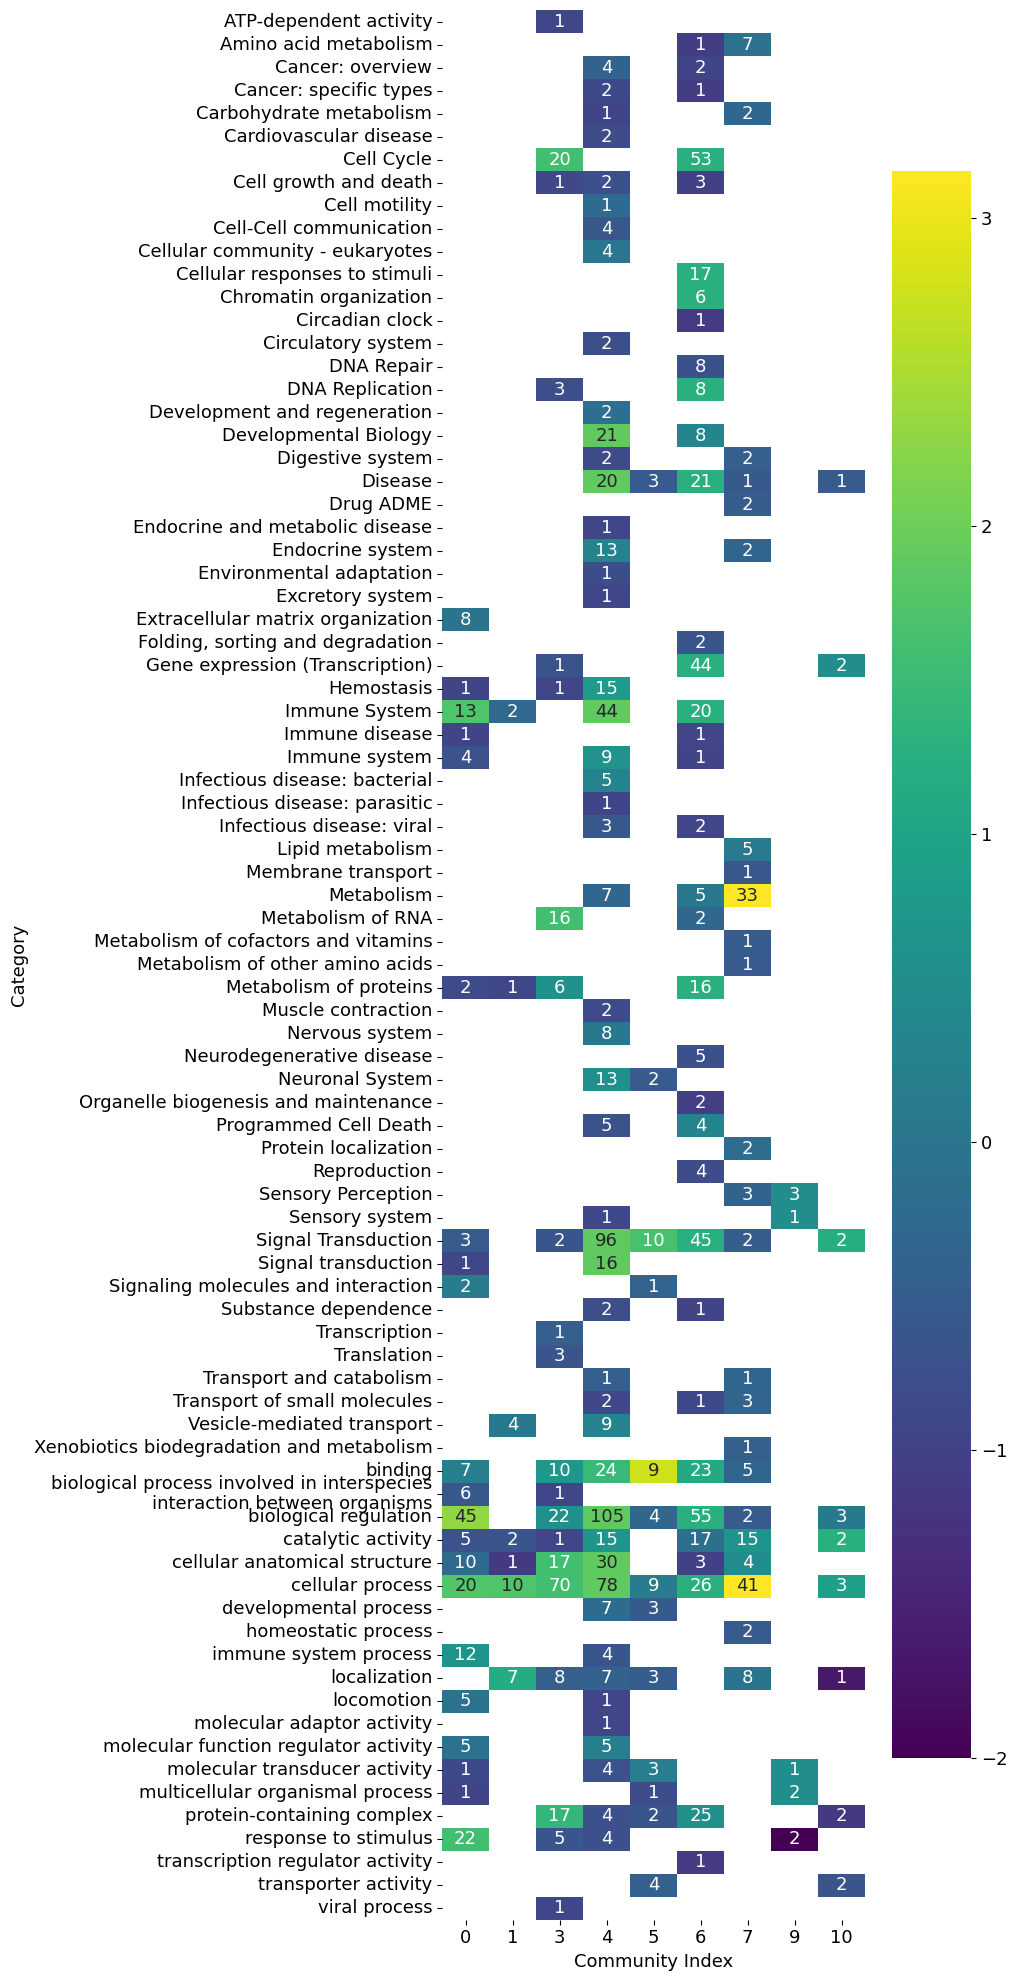

In [33]:
heat_df = community_categories_filtered.pivot(
    index="Category",
    columns="Community Index",
    values="fisher_z"
).reindex(columns = top_5_comm_indices)

label_df = community_categories_filtered.pivot(
    index="Category",
    columns="Community Index",
    values="count"
).reindex(columns = top_5_comm_indices)
plt.figure(figsize=(10,20))
ax = sns.heatmap(
    heat_df,
    cmap="viridis",
    annot=label_df,   # <-- use count for labels
    fmt=".0f",        # integer labels
    cbar=True
)

# ---- WRAP Y-AXIS LABELS ----
MAX_CHARS = 50  # tweak this
wrapped = ["\n".join(textwrap.wrap(str(s), width=MAX_CHARS)) for s in heat_df.index]
ax.set_yticklabels(wrapped, rotation=0)  # keep horizontal

plt.tight_layout()
plt.savefig(f"../../Graphs/{DISEASE}/category_gross_overlap_heatmap.png", bbox_inches="tight")
plt.show()
